In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, 
    f1_score, confusion_matrix, classification_report, roc_auc_score
)

pd.set_option('display.max_columns', None)
sns.set(style="whitegrid")


In [19]:
### Loading Preprocessed Data

In [5]:
# Load the train/test splits saved from preprocessing
X_train = pd.read_csv("X_train.csv")
X_test = pd.read_csv("X_test.csv")
y_train = pd.read_csv("y_train.csv").values.ravel()  # ravel to convert to 1D array
y_test = pd.read_csv("y_test.csv").values.ravel()

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (23972, 23)
X_test shape: (5993, 23)
y_train shape: (23972,)
y_test shape: (5993,)


In [7]:
# Logistic Regression - simple baseline model
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train, y_train)

# Predictions
y_pred_log = log_reg.predict(X_test)

# Evaluation
print("Logistic Regression Results")
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("Precision:", precision_score(y_test, y_pred_log))
print("Recall:", recall_score(y_test, y_pred_log))
print("F1 Score:", f1_score(y_test, y_pred_log))
print("\nClassification Report:\n", classification_report(y_test, y_pred_log))

Logistic Regression Results
Accuracy: 0.8097780744201568
Precision: 0.6978723404255319
Recall: 0.2473604826546003
F1 Score: 0.36525612472160357

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.97      0.89      4667
           1       0.70      0.25      0.37      1326

    accuracy                           0.81      5993
   macro avg       0.76      0.61      0.63      5993
weighted avg       0.79      0.81      0.77      5993



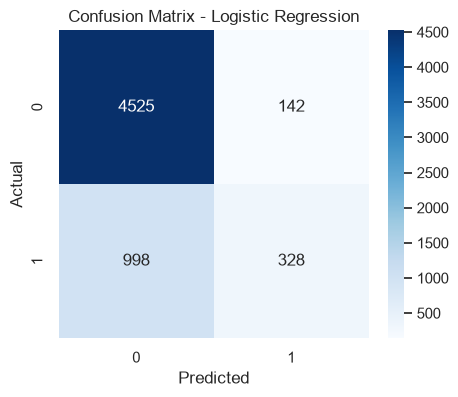

In [8]:
cm = confusion_matrix(y_test, y_pred_log)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
### Decision Tree Classifier

In [9]:
dt = DecisionTreeClassifier(random_state=42, max_depth=6)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("Decision Tree Results")
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt))
print("Recall:", recall_score(y_test, y_pred_dt))
print("F1 Score:", f1_score(y_test, y_pred_dt))
print("\nClassification Report:\n", classification_report(y_test, y_pred_dt))

Decision Tree Results
Accuracy: 0.8166193892875021
Precision: 0.654421768707483
Recall: 0.3627450980392157
F1 Score: 0.46676370693837943

Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.95      0.89      4667
           1       0.65      0.36      0.47      1326

    accuracy                           0.82      5993
   macro avg       0.75      0.65      0.68      5993
weighted avg       0.80      0.82      0.80      5993



In [20]:
### K-Nearest Neighbors (KNN) Classifier

In [10]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)

print("KNN Results")
print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print("Precision:", precision_score(y_test, y_pred_knn))
print("Recall:", recall_score(y_test, y_pred_knn))
print("F1 Score:", f1_score(y_test, y_pred_knn))
print("\nClassification Report:\n", classification_report(y_test, y_pred_knn))

KNN Results
Accuracy: 0.7904221591857167
Precision: 0.5423728813559322
Recall: 0.3378582202111614
F1 Score: 0.4163568773234201

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.92      0.87      4667
           1       0.54      0.34      0.42      1326

    accuracy                           0.79      5993
   macro avg       0.69      0.63      0.64      5993
weighted avg       0.77      0.79      0.77      5993



In [21]:
### Random Forest Classifier (Ensemble Method)

In [11]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest Results")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

Random Forest Results
Accuracy: 0.8124478558318038
Precision: 0.6343085106382979
Recall: 0.3597285067873303
F1 Score: 0.4590952839268527

Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.94      0.89      4667
           1       0.63      0.36      0.46      1326

    accuracy                           0.81      5993
   macro avg       0.74      0.65      0.67      5993
weighted avg       0.79      0.81      0.79      5993



In [22]:
### Model Comparison
#Comparing all baseline models using Accuracy, Precision, Recall, and F1-score. Since the target 
#is imbalanced, F1-score is the primary metric for model selection rather than Accuracy alone.

SyntaxError: invalid syntax (4003097265.py, line 2)

In [12]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'KNN', 'Random Forest'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_knn),
        accuracy_score(y_test, y_pred_rf)
    ],
    'Precision': [
        precision_score(y_test, y_pred_log),
        precision_score(y_test, y_pred_dt),
        precision_score(y_test, y_pred_knn),
        precision_score(y_test, y_pred_rf)
    ],
    'Recall': [
        recall_score(y_test, y_pred_log),
        recall_score(y_test, y_pred_dt),
        recall_score(y_test, y_pred_knn),
        recall_score(y_test, y_pred_rf)
    ],
    'F1 Score': [
        f1_score(y_test, y_pred_log),
        f1_score(y_test, y_pred_dt),
        f1_score(y_test, y_pred_knn),
        f1_score(y_test, y_pred_rf)
    ]
})

results = results.sort_values(by='F1 Score', ascending=False)
print(results)

                 Model  Accuracy  Precision    Recall  F1 Score
1        Decision Tree  0.816619   0.654422  0.362745  0.466764
3        Random Forest  0.812448   0.634309  0.359729  0.459095
2                  KNN  0.790422   0.542373  0.337858  0.416357
0  Logistic Regression  0.809778   0.697872  0.247360  0.365256


In [ ]:
### Feature Importance
#Using Random Forest to identify which features most influence default prediction. PAY_0 
#(most recent repayment status) is the strongest predictor, followed by AGE and LIMIT_BAL — 
#consistent with EDA findings.

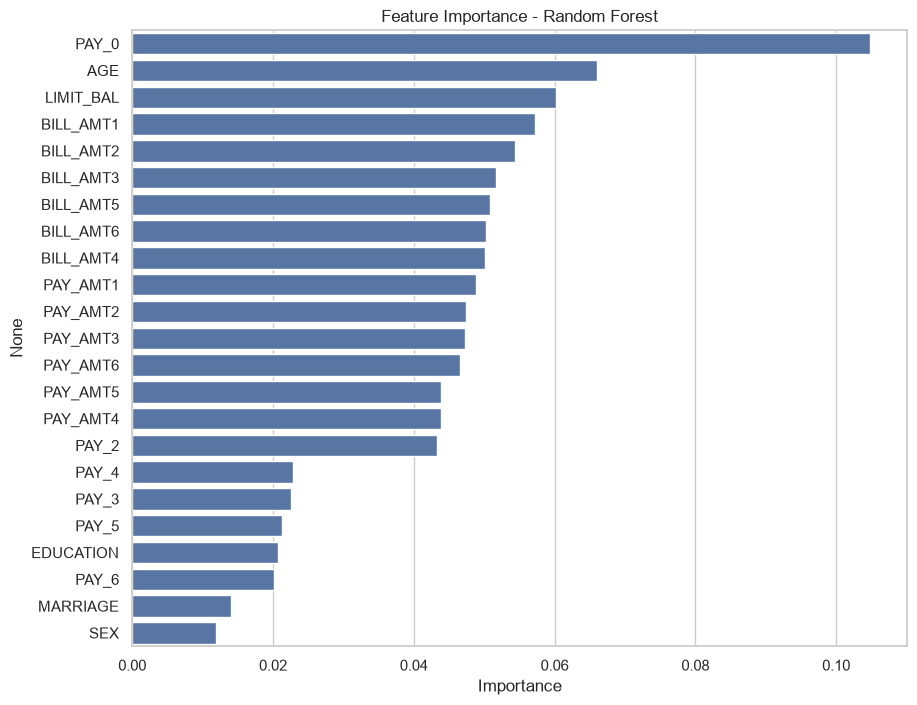

In [13]:
importances = pd.Series(rf.feature_importances_, index=X_train.columns)
importances = importances.sort_values(ascending=False)

plt.figure(figsize=(10,8))
sns.barplot(x=importances.values, y=importances.index)
plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance")
plt.show()

In [ ]:
### Hyperparameter Tuning
#Using GridSearchCV with 3-fold cross-validation to find the best Random Forest configuration, 
#optimizing for F1-score. Testing `class_weight='balanced'` to address class imbalance.

In [14]:
from sklearn.model_selection import GridSearchCV

# Define parameter grid to search
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [6, 10, None],
    'min_samples_split': [2, 5],
    'class_weight': [None, 'balanced']  # 'balanced' helps with imbalanced target
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=3,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

rf_grid.fit(X_train, y_train)

print("Best Parameters:", rf_grid.best_params_)
print("Best CV F1 Score:", rf_grid.best_score_)

Fitting 3 folds for each of 24 candidates, totalling 72 fits
Best Parameters: {'class_weight': 'balanced', 'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}
Best CV F1 Score: 0.5459635111470095


In [ ]:
### Hyperparameter Tuning
#Using GridSearchCV with 3-fold cross-validation to find the best Random Forest configuration, 
#optimizing for F1-score. Testing `class_weight='balanced'` to address class imbalance.

In [15]:
# Use the best model found by GridSearchCV
best_rf = rf_grid.best_estimator_

y_pred_best = best_rf.predict(X_test)

print("Tuned Random Forest Results (Test Set)")
print("Accuracy:", accuracy_score(y_test, y_pred_best))
print("Precision:", precision_score(y_test, y_pred_best))
print("Recall:", recall_score(y_test, y_pred_best))
print("F1 Score:", f1_score(y_test, y_pred_best))
print("ROC-AUC:", roc_auc_score(y_test, best_rf.predict_proba(X_test)[:,1]))
print("\nClassification Report:\n", classification_report(y_test, y_pred_best))

Tuned Random Forest Results (Test Set)
Accuracy: 0.7722342733188721
Precision: 0.4876504116529449
Recall: 0.5806938159879337
F1 Score: 0.5301204819277109
ROC-AUC: 0.7706822654231873

Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.83      0.85      4667
           1       0.49      0.58      0.53      1326

    accuracy                           0.77      5993
   macro avg       0.68      0.70      0.69      5993
weighted avg       0.79      0.77      0.78      5993



In [ ]:
### Final Model Evaluation
#Evaluating the tuned Random Forest on the test set. F1-score improved from 0.459 (default RF) 
#to 0.530 (tuned), with Recall improving significantly from 0.36 to 0.58 — meaning the model now 
#identifies far more actual defaulters, which is critical for a credit risk use case.

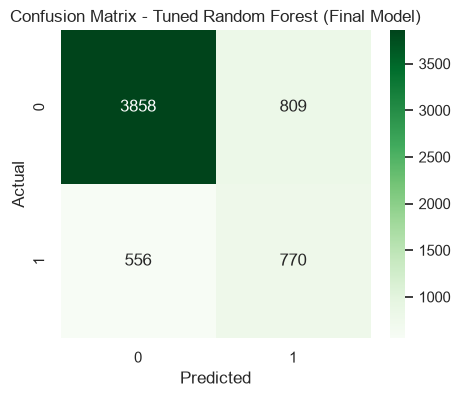

In [16]:
cm_best = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(5,4))
sns.heatmap(cm_best, annot=True, fmt='d', cmap='Greens')
plt.title("Confusion Matrix - Tuned Random Forest (Final Model)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
### Final Model Comparison
#The Tuned Random Forest outperforms all baseline models on F1-score (0.530), making it the 
#selected final model despite a slightly lower accuracy — a reasonable tradeoff given the 
#business cost of missing defaulters.

In [17]:
final_results = pd.concat([
    results,
    pd.DataFrame({
        'Model': ['Tuned Random Forest'],
        'Accuracy': [accuracy_score(y_test, y_pred_best)],
        'Precision': [precision_score(y_test, y_pred_best)],
        'Recall': [recall_score(y_test, y_pred_best)],
        'F1 Score': [f1_score(y_test, y_pred_best)]
    })
], ignore_index=True)

final_results = final_results.sort_values(by='F1 Score', ascending=False)
print(final_results)

                 Model  Accuracy  Precision    Recall  F1 Score
4  Tuned Random Forest  0.772234   0.487650  0.580694  0.530120
0        Decision Tree  0.816619   0.654422  0.362745  0.466764
1        Random Forest  0.812448   0.634309  0.359729  0.459095
2                  KNN  0.790422   0.542373  0.337858  0.416357
3  Logistic Regression  0.809778   0.697872  0.247360  0.365256


In [18]:
import joblib

# Save the trained model to a file for future use
joblib.dump(best_rf, "final_model_random_forest.pkl")
print("Model saved as 'final_model_random_forest.pkl'")

Model saved as 'final_model_random_forest.pkl'
